Boissier, S., & Prantzos, N. 1999, MNRAS, 307, 857

Boissier, S., & Prantzos, N. 2000, MNRAS, 312, 398

mc-spf DATA/Coma/NGC4848/region_photometry.fits filters.txt --sfh 'SFHs_Boissier/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FITPHOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' --timerange '12500,13500' PLOT

mc-spf DATA/GMP3779/region_photometry.fits filters.txt --sfh 'SFHs_Boisser/Models_B120VEL_radius_5_Z0.020_bc03hr.fits' FIT



# Scaling relation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Scaling relations

Rd_MW = 2.6                # kpc
Sigma_0_MW = 1150          # solar masses / pc2
Vc_MW = 220                # km/s
spin_MW = 0.03 
md_MW = 0.05
M_MW = 1e12                 # Msun
Md_MW = 0.05 * 1e12         # Msun

md = 0.05
jd = 0.05

def M(Vc):
    return  M_MW * (Vc / Vc_MW)**3

def Md(Vc,md):
    return  md * M(Vc)

def Rd(Vc,spin):
    return  Rd_MW * (spin / spin_MW) * (Vc / Vc_MW)

def Sigma_0(Vc,spin): 
    return Sigma_0_MW * (md / md_MW) * (spin / spin_MW)**-2 * (Vc / Vc_MW)

def surface_density(R,Vc,spin):
    return Sigma_0(Vc,spin) * np.exp(-R/Rd(Vc,spin))


def Vc_to_Md(Vc): return Md(Vc,md = 0.05)
def Md_to_Vc(Md): return Vc_MW * (Md / Md_MW)**(1/3)
    

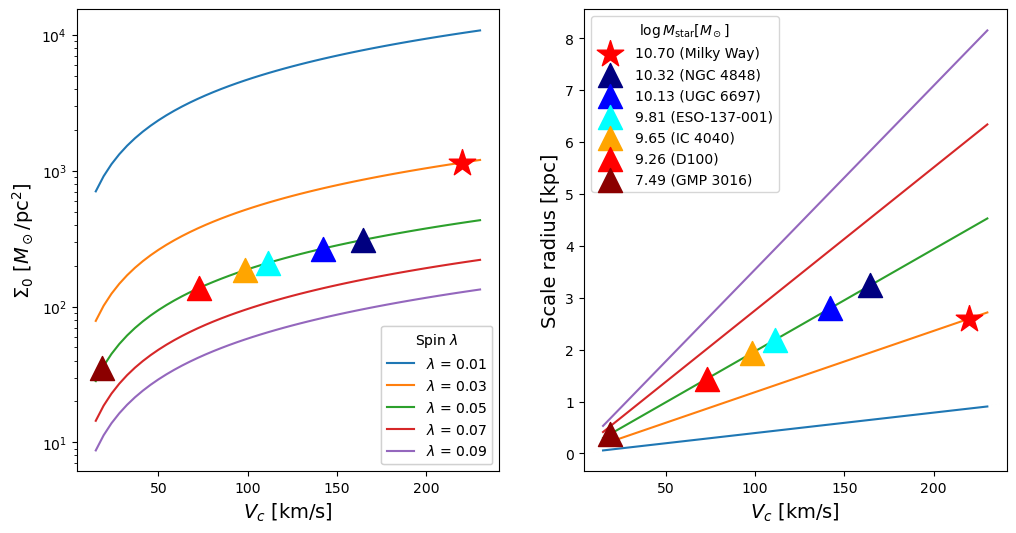

In [3]:
# --- Galaxy Sample ---
sample_galaxies = {
    'NGC 4848': 10.32,
    'UGC 6697': 10.13,
    'ESO-137-001': 9.81,
    'IC 4040': 9.65,
    'D100': 9.26,
    'GMP 3016': 7.49
}

colors = ['navy','blue', 'cyan', 'orange', 'red', 'darkred']

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
v = np.linspace(15, 230)

# Plot model curves for different spin parameters
spin_values = [0.01, 0.03, 0.05, 0.07, 0.09]
spin_handles = []

for l in spin_values:
    h0, = ax[0].plot(v, Sigma_0(v, l), label=f'$\lambda$ = {l:.2f}')
    h1, = ax[1].plot(v, Rd(v, l), label=f'$\lambda$ = {l:.2f}')
    spin_handles.append(h0)  # store only one handle per spin


galaxy_handles = []
h = ax[0].scatter(Vc_MW, Sigma_0_MW, marker='*', c='red', edgecolor='red', s=400, label=f"{np.log10(Vc_to_Md(220)):.2f} (Milky Way)",zorder=5)
ax[1].scatter(Vc_MW, Rd_MW, marker='*', c='red', edgecolor='red', s=400,zorder=5)
galaxy_handles.append(h)

for i, gal in enumerate(sample_galaxies.keys()):
    logMd = sample_galaxies[gal]
    Md_val = 10**logMd
    Vc_gal = Md_to_Vc(Md_val)
    Sigma_0_gal = Sigma_0(Vc_gal, 0.05)
    Rd_gal = Rd(Vc_gal, 0.05)

    h = ax[0].scatter(Vc_gal, Sigma_0_gal, color = colors[i], marker='^', s=300, label=f"{sample_galaxies[gal]} ({gal})",zorder=5)
    ax[1].scatter(Vc_gal, Rd_gal, color = colors[i], marker='^', s=300,zorder=5)
    galaxy_handles.append(h)

# Axis labels
for i in range(2):
    ax[i].set_xlabel('$V_c$ [km/s]',fontsize=14)
ax[0].set_ylabel(r'$\Sigma_0$ [$M_\odot$/pc$^2$]',fontsize=14)
ax[1].set_ylabel('Scale radius [kpc]',fontsize=14)
ax[0].set_yscale('log')

# Two legends on left panel
spin_legend = ax[0].legend(handles=spin_handles, loc='lower right', title='Spin $\lambda$')
ax[0].add_artist(spin_legend)
ax[1].legend(handles=galaxy_handles, loc='upper left', title='$\log M_\\text{star} [M_\odot]$')

# Secondary axes created ONCE and BEFORE plt.show()
#secax0 = ax[0].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax1 = ax[1].secondary_xaxis('top', functions=(Vc_to_Md, Md_to_Vc))
#secax0.set_xlabel('$M_d$ [$M_\\odot$]')
#secax1.set_xlabel('$M_d$ [$M_\\odot$]')

#plt.tight_layout()
plt.show()



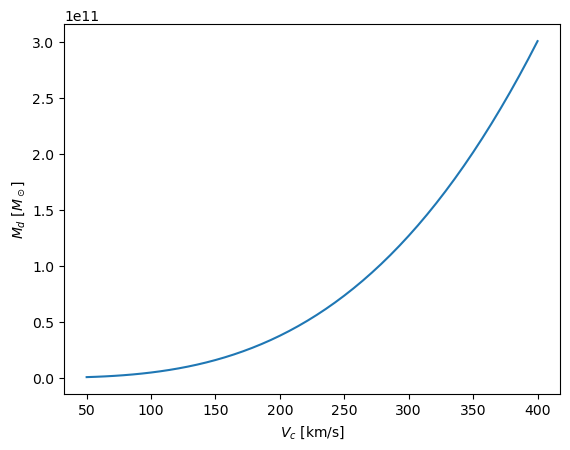

In [4]:
V_array = np.linspace(50,400)

fig,ax=plt.subplots()
ax.plot(V_array, Vc_to_Md(V_array))
#ax.set_aspect('equal')

ax.set_xlabel('$V_c$ [km/s]')
ax.set_ylabel('$M_d$ [$M_\odot$]')

plt.show()


In [5]:
# Velocity curves
from scipy.interpolate import interp1d
from scipy.special import iv as I, kv as K

G = 4.301e-6         # (kpc * (km/s)^2) / M_sun
rho0 = 0.015 * 1e9   # M_sun/kpc^3   0.008 - 0.015
Rc_MW = 5            # kpc -5 to 10

def Rc(Vc,spin):
    return Rc_MW * (spin/spin_MW) * (Vc/Vc_MW)

def rho_0(Vc,spin):
    return Vc**2 / (4*np.pi*G*Rc(Vc,spin)**2)


def velocity_profile(Vc, spin, disk=True):

    R = np.linspace(0.03, 50, 500)

    # Disk component
    sigma_0 = Sigma_0(Vc, spin)
    rd = Rd(Vc, spin)
    y = R / (2*rd)
    Vd_squared = 4 * np.pi * G * (sigma_0 * 1e6) * rd * y**2 * (I(0, y) * K(0, y) - I(1, y) * K(1, y))
    
    # Halo component
    rho0_val = rho_0(Vc, spin)
    rc = Rc(Vc, spin)
    Vh_squared = 4 * np.pi * G * rho0_val * rc**2 * (1 - (rc / R) * np.arctan(R / rc))

    # Total rotation curve
    V_total = np.sqrt(Vd_squared + Vh_squared)

    V_interp = interp1d(R, V_total, kind='linear', bounds_error=False, fill_value='extrapolate')

    return V_interp


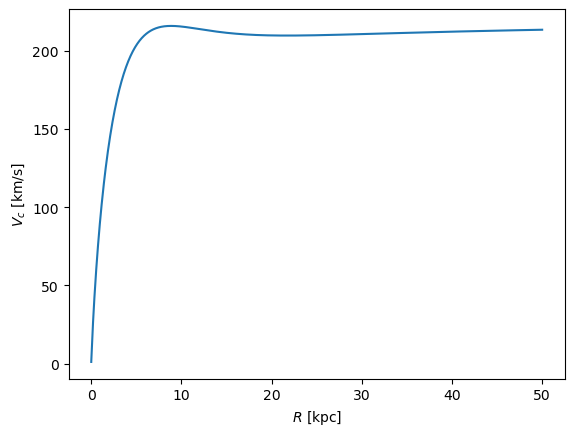

In [6]:
fig,ax = plt.subplots()

r = np.linspace(0,50,1000)
plt.plot(r,velocity_profile(220,0.03)(r))

ax.set_xlabel('$R$ [kpc]')
ax.set_ylabel('$V_c$ [km/s]')

plt.show()

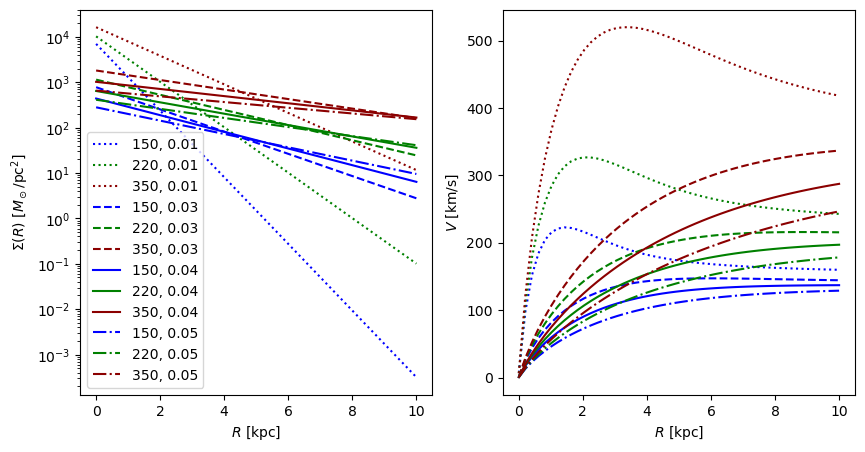

In [7]:
fig,ax = plt.subplots(1,2,figsize=(10,5))


r = np.linspace(0,10)

for l,ls in zip([0.01,0.03,0.04,0.05], [':','--','-','-.']):
    for Vc,c in zip([150,220,350], ['blue','green','darkred']):

        ax[0].plot(r,surface_density(r,Vc,l),linestyle=ls,color=c,label=f'{Vc}, {l}')
        ax[0].set_yscale('log')
        ax[0].set_xlabel('$R$ [kpc]')
        ax[0].set_ylabel('$\Sigma(R)$ [$M_\odot$/pc$^2$]')

        ax[0].legend()
        
        ax[1].plot(r, velocity_profile(Vc,l)(r),linestyle=ls,color=c)
        ax[1].set_xlabel('$R$ [kpc]')
        ax[1].set_ylabel('$V$ [km/s]')


# Boissier models

In [8]:
import os, glob, re
import numpy as np
from astropy.io import fits
import tempfile

# Base directory containing the “DISKEVOL.RES_L0.05_V*” files
data_dir = "SFHs_Boissier/boissier_models_big_grid"

# Pattern to match files without “lignes” in their name
file_pattern = os.path.join(data_dir, "DISKEVOL.RES_L0.05_V*")

# Regex to extract the integer velocity after “_V”
vel_pattern = re.compile(r"_V(\d+)")
# First, collect (velocity, full_path) pairs
velocity_files = []
for full_path in glob.glob(file_pattern):
    fname = os.path.basename(full_path)
    if "lignes" in fname:
        continue
    m = vel_pattern.search(fname)
    if not m:
        continue
    velocity = int(m.group(1))
    velocity_files.append((velocity, full_path))

# Sort by velocity (ascending)
velocity_files.sort(key=lambda vf: vf[0])

# Now build the dictionary in sorted order
boissier_models = {}
for velocity, full_path in velocity_files:
    boissier_models[velocity] = {}   # Initialize nested dict for this velocity

    current_radius = None
    boissier_models_by_radius = {}   # Temporary storage: radius → list of rows

    with open(full_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("99999"):
                # Skip empty lines or separator lines
                continue

            if line.startswith("R ="):
                parts = line.split()
                try:
                    # Parse “R = 1.24 kpc” → radius = 1.24
                    current_radius = float(parts[2])
                    boissier_models_by_radius[current_radius] = []
                except (IndexError, ValueError):
                    current_radius = None
                continue

            if current_radius is None:
                continue

            parts = line.split()
            if len(parts) < 6:
                continue

            try:
                # Convert columns 1–5 to float
                row = [float(x) for x in parts[1:6]]
                boissier_models_by_radius[current_radius].append(row)
            except ValueError:
                continue

    # Convert each list of rows into a NumPy array, then store under data[velocity]
    for radius, rows in boissier_models_by_radius.items():
        boissier_models[velocity][radius] = np.array(rows)

# Example: print out velocity → radius → array shape (velocities will be in ascending order)
#for v in data:
#    for r in sorted(data[v]):
#        arr = data[v][r]
#        print(f"Velocity = {v} km/s, Radius = {r:.2f} kpc → Shape = {arr.shape}")



In [8]:
from build_boissier import unperturbed_boissier_sfh, truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits


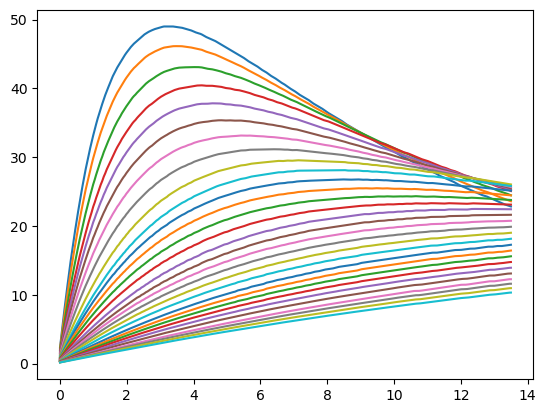

In [10]:
for R in np.linspace(1,10,30):
    sfh = unperturbed_boissier_sfh(V=160,R=R)
    t     = sfh[:, 0]
    sigma = sfh[:, 1]
    sfr   = sfh[:, 2]
    Z     = sfh[:, 3]
    
    plt.plot(t,sfr)

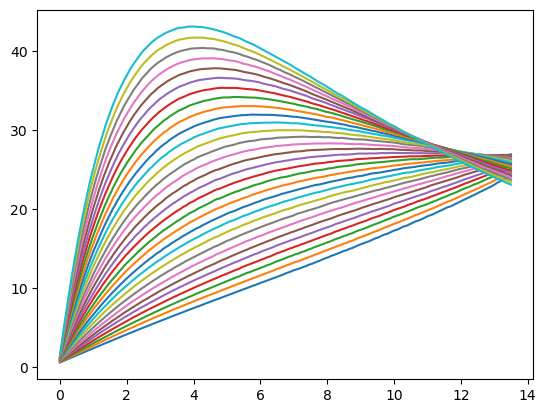

In [11]:
for V in np.linspace(80,200,30):
    sfh = unperturbed_boissier_sfh(V=V,R=Rd(V,spin=0.05))
    t     = sfh[:, 0]
    sigma = sfh[:, 1]
    sfr   = sfh[:, 2]
    Z     = sfh[:, 3]
    
    plt.plot(t,sfr)

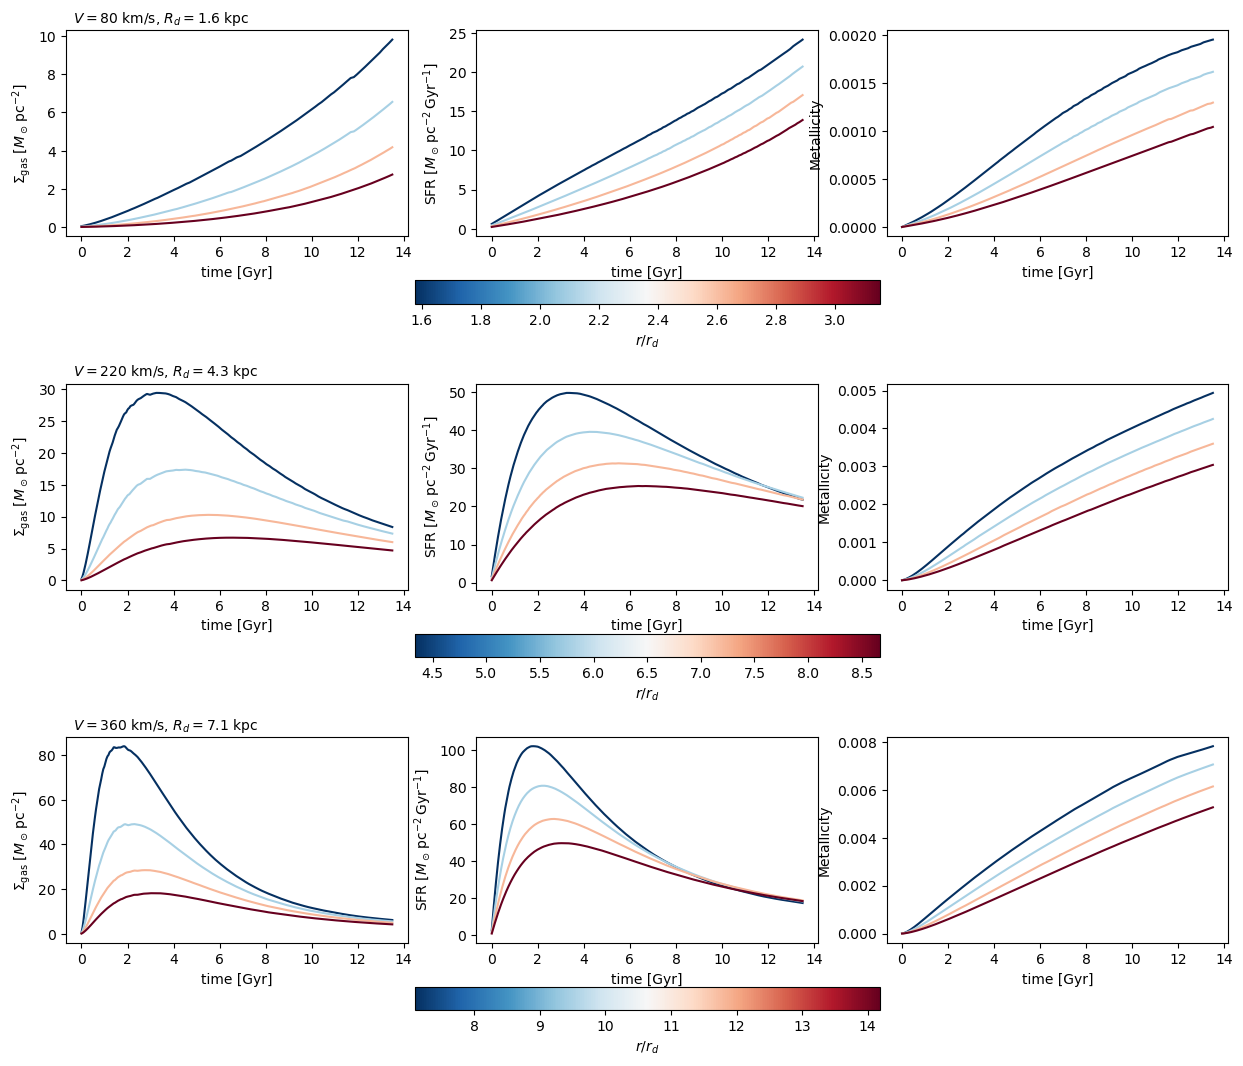

In [12]:
fig, ax = plt.subplots(3, 3, figsize=(15, 13))

for k, V in enumerate([80, 220, 360]):

    rd = Rd(V, 0.05)   # scale radius

    r_min, r_max = 1*rd, 2*rd
    radii = np.linspace(r_min,r_max,4)

    norm = plt.Normalize(vmin=r_min, vmax=r_max)
    cmap = plt.cm.RdBu_r

    
    for R in radii:

        c = cmap(norm(R))

        sfh = unperturbed_boissier_sfh(V, R)

        t     = sfh[:, 0]
        sigma = sfh[:, 1]
        sfr   = sfh[:, 2]
        Z     = sfh[:, 3]

        ax[k, 0].plot(t, sigma, color=c)
        ax[k, 1].plot(t, sfr,   color=c)
        ax[k, 2].plot(t, Z,     color=c)

    # --- Colorbar ---
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(radii)
    cbar = fig.colorbar(
        sm, ax=ax[k, :],
        orientation='horizontal',
        pad=0.15, shrink=0.4
    )
    cbar.set_label(r"$r / r_d$")

    # --- Labels ---
    for i in range(3):
        ax[k, i].set_xlabel("time [Gyr]")

    ax[k, 0].set_ylabel(r"$\Sigma_{\rm gas}$ [$M_\odot\,\mathrm{pc}^{-2}$]")
    ax[k, 1].set_ylabel(r"SFR [$M_\odot\,\mathrm{pc}^{-2}\,\mathrm{Gyr}^{-1}$]")
    ax[k, 2].set_ylabel("Metallicity")

    ax[k, 0].text(
        0.02, 1.1,
        rf"$V={V}$ km/s, $R_d={rd:.1f}$ kpc",
        transform=ax[k, 0].transAxes,
        va="top", ha="left"
    )

plt.show()

In [9]:
t,sfr = truncated_boissier_sfh(V=160,R=1,Q_age=150,tau_Q=5,burst_factor=2,)

(13000.0, 13500.0)

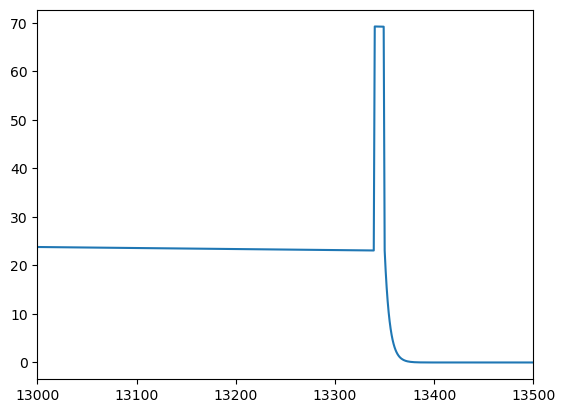

In [10]:
plt.plot(t,sfr)
plt.xlim(13000,13500)

In [11]:
# SFH quenching  #Lookback time for quenching Myr and attenuation factor for quenching
SFH_QUENCHING_TAU    = [2,4,8,12,16,20,24,28,35,45,75,100,125,150,175,200,250,300,350,400,450,500,600,700,800,900,1000,2000]
SFH_QUENCHING_AGE    = [4,8,10,20,30,50,70,90,100,140,180,200,240,280,300,350,400,450,500,550,600,650,700,750,800,900,1000,1500,2000,2500,3000]
#SFH_QUENCHING_TAU    = [1,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,35,40,45,50,75,100,125,150,175,200,250,300,350,400,450,500,600,700,800,900,1000,2000]
#SFH_QUENCHING_AGE    = [2,4,6,8,10,20,30,40,50,60,70,80,90,100,120,140,160,180,200,220,240,260,280,300,325,350,375,400,425,450,475,500,550,600,650,700,750,800,850,900,950,1000,1500,2000,2500,3000]

BURST_FACTOR = [0]      #,0.5,1,5,10,100]
METALLICITIES = [0.017] #[0.008,0.014,0.017,0.02,0.03] 




In [16]:
specs = build_boissier_SEDs(V=160,R=7.5,
                                SFH_QUENCHING_AGE=SFH_QUENCHING_AGE,
                                SFH_QUENCHING_TAU=SFH_QUENCHING_TAU,
                                BURST_FACTORS=BURST_FACTOR,
                                METALLICITIES=METALLICITIES,
                                filename='V_160_R_7.fit',
                                data=boissier_models)


Generating 868 models


Processing combinations: 100%|████████████████| 868/868 [22:56<00:00,  1.59s/it]


In [ ]:
specs = build_boissier_SEDs(V=160,R=10,
                                SFH_QUENCHING_AGE=SFH_QUENCHING_AGE,
                                SFH_QUENCHING_TAU=SFH_QUENCHING_TAU,
                                BURST_FACTORS=BURST_FACTOR,
                                METALLICITIES=METALLICITIES,
                                filename='V_160_R_10.fit',)

Generating 868 models


Processing combinations:   1%|▎                | 13/868 [00:16<17:07,  1.20s/it]

In [18]:

from pangal.pfitter import PFitter
from build_boissier import load_spectrum_models_from_fits


In [19]:
model_specs = load_spectrum_models_from_fits(filename='V_160_R_7_short.fit')

In [20]:
fitter = PFitter(model_specs,
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )

Initializing PFitter object
   Model parameters: Q_AGE, TAU_Q, BURST, METAL

 Pre-computed model grid:
   - Q_AGE: 6 values, min=10, max=4000
   - TAU_Q: 4 values, min=10, max=1000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 

# Try different Q_age with same tau

In [21]:
# MODEL PARAMETERS
vel_sys = 173
sigma_vel = 80

fesc = 0.1
ion_gas = -2.0
age_gas = 11

av = 0.0939
av_ext = 0.1
alpha = 1.775

m_star = 9.30
redshift = 0.023974
luminosity_distance = 100

TAU_Q = 10
BURST = 0
METAL = 0.017

specs = []

for q_age in [100,4000]:

    
    
    sytnh_spec = fitter.synthetic_spectrum(
        vel_sys=vel_sys,
        sigma_vel=sigma_vel,
        av=av,av_ext=av_ext,alpha=alpha,
        fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
        Q_AGE=q_age,
        TAU_Q=TAU_Q,
        BURST=0,METAL=0.017,
        m_star=m_star,
        redshift=redshift,luminosity_distance=luminosity_distance)
    specs.append(sytnh_spec)
    

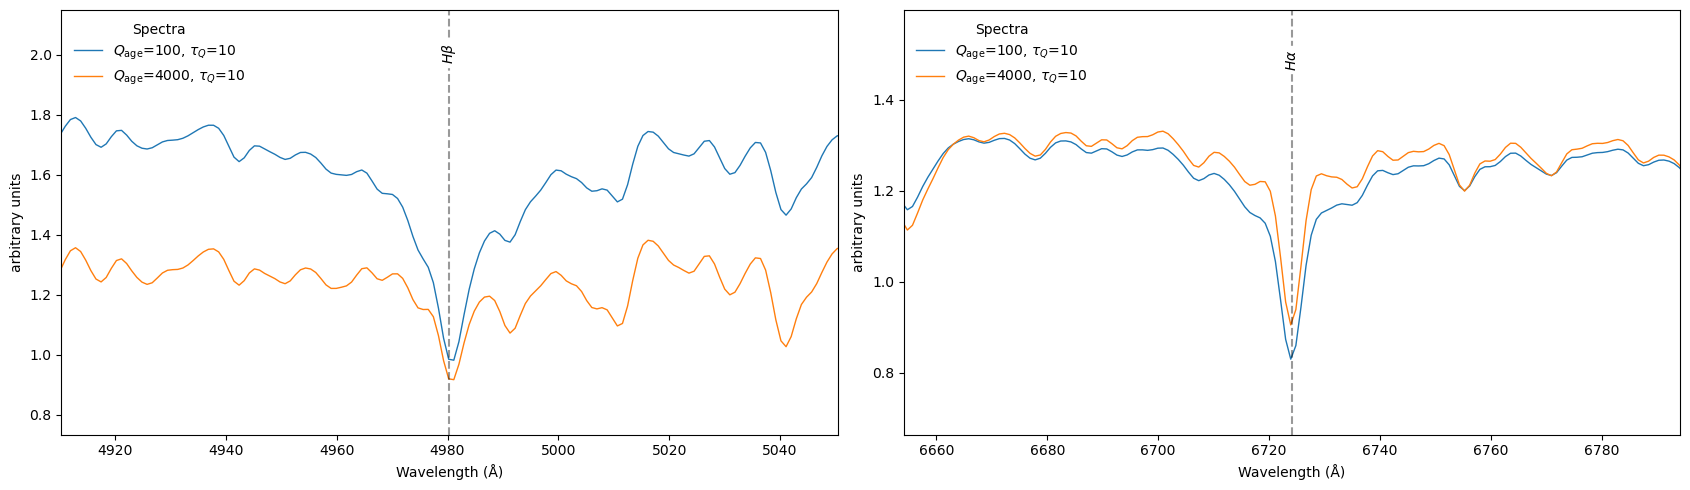

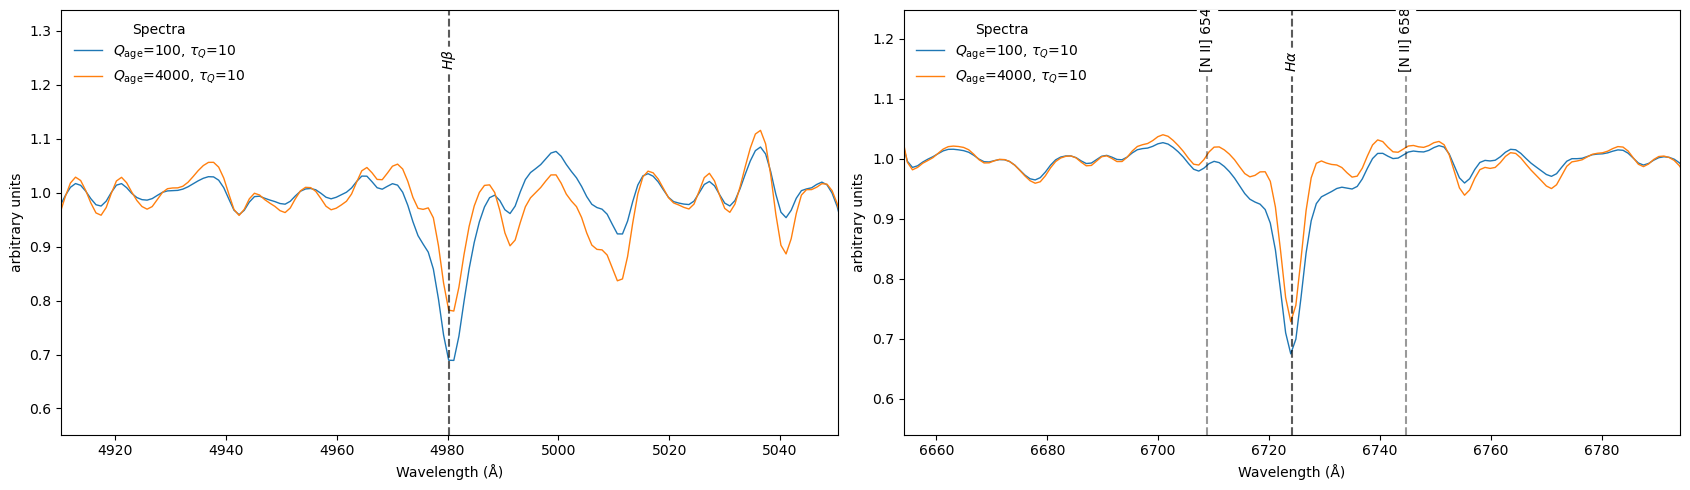

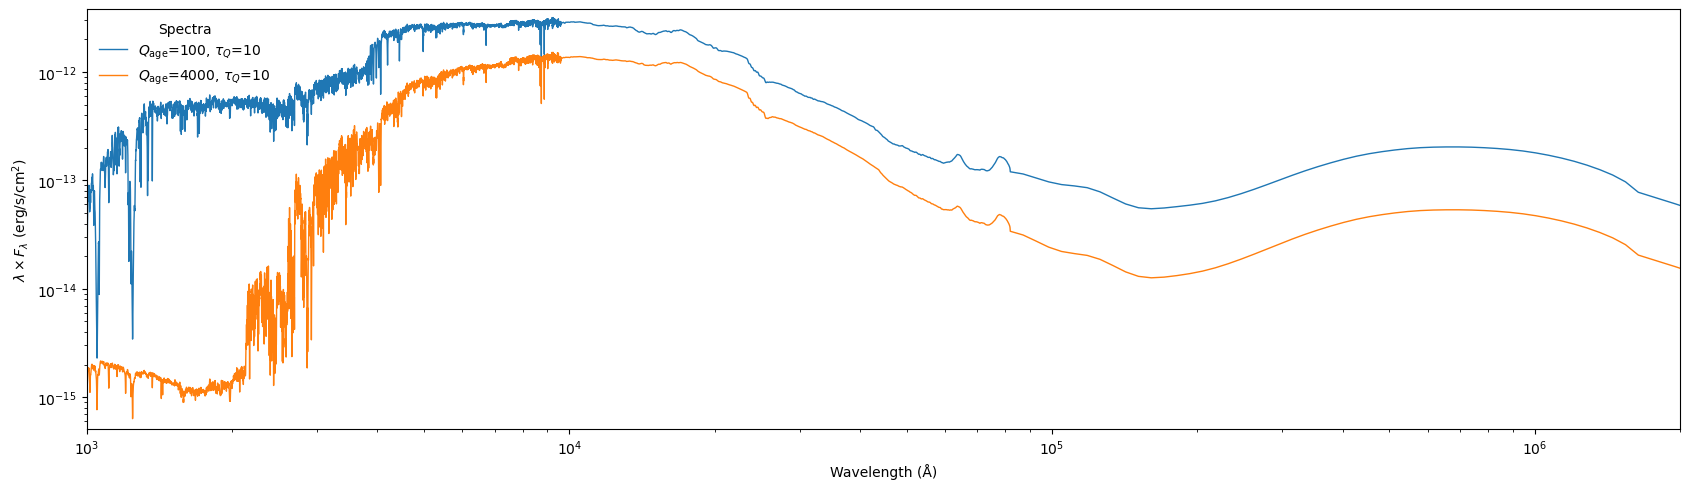

In [22]:
legend = {'Q_AGE': "$Q_\\text{age}$", 'TAU_Q': "$\\tau_Q$",} #'BURST': 'burst', 'METAL': 'metallicity'

specs[0].plot(figsize=(20,5), 
            #remove_continuum=True,
              #draw_continuum=True,                      
             spectra=specs,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            normalized=True,
            #per_wavelength=True, 
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Hb','Ha'],
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs[0].plot(figsize=(20,5), 
            remove_continuum=True,
              #draw_continuum=True,                      
             spectra=specs,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Hb','Ha'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs[0].plot(figsize=(20,5), 
            #remove_continuum=True,
            #draw_continuum=True,                      
             spectra=specs,
            #normalized=True,
            per_wavelength=True, 
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
            spec_legend=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )
